In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('C:/Users/Javier/Documents/Python Scripts/Data_fraud.csv',sep=',',decimal='.')
print(df.head())

#data were taken from OpenML https://www.openml.org/search?type=data&status=active&id=45955

   distance_from_home  distance_from_last_transaction  \
0           57.877857                        0.311140   
1           10.829943                        0.175592   
2            5.091079                        0.805153   
3            2.247564                        5.600044   
4           44.190936                        0.566486   

   ratio_to_median_purchase_price  repeat_retailer  used_chip  \
0                        1.945940              1.0        1.0   
1                        1.294219              1.0        0.0   
2                        0.427715              1.0        0.0   
3                        0.362663              1.0        1.0   
4                        2.222767              1.0        1.0   

   used_pin_number  online_order  fraud  
0              0.0           0.0    0.0  
1              0.0           0.0    0.0  
2              0.0           1.0    0.0  
3              0.0           1.0    0.0  
4              0.0           1.0    0.0  


**Attribute Description**

1. *distance_from_home:* This is a numerical feature representing the geographical distance in kilometers between the transaction location and the cardholder's home address.
2. *distance_from_last_transaction:* This numerical attribute measures the distance in kilometers from the location of the last transaction to the current transaction location.
3. *ratio_to_median_purchase_price:* A numeric ratio that compares the transaction's price to the median purchase price of the user's transaction history.
4. *repeat_retailer:* A binary attribute where '1' signifies that the transaction was conducted at a retailer previously used by the cardholder, and '0' indicates a new retailer.
5. *used_chip:* This binary feature indicates whether the transaction was made using a chip (1) or not (0).
6. *used_pin_number:* Another binary feature, where '1' signifies the use of a PIN number for the transaction, and '0' shows no PIN number was used.
7. *online_order:* This attribute identifies whether the purchase was made online ('1') or offline ('0').
8. *fraud:* A binary target variable indicating whether the transaction was fraudulent ('1') or not ('0').

**Use Case:** This dataset is particularly suited for developing machine learning models to detect potentially fraudulent transactions. Financial institutions and cybersecurity firms can leverage this data to enhance their fraud detection systems, ensuring safer transaction environments for cardholders. Researchers in fintech and cybersecurity can also use this dataset for academic purposes, exploring new methodologies in fraud detection algorithms. Additionally, policy makers and regulatory bodies can analyze trends and patterns to formulate guidelines that mitigate transactional fraud.

In [3]:
df.dtypes

distance_from_home                float64
distance_from_last_transaction    float64
ratio_to_median_purchase_price    float64
repeat_retailer                   float64
used_chip                         float64
used_pin_number                   float64
online_order                      float64
fraud                             float64
dtype: object

In [44]:
df2=df
df2['fraud'] = df2['fraud'].astype('object')
df2['repeat_retailer'] = df2['repeat_retailer'].astype('object')
df2['used_chip'] = df2['used_chip'].astype('object')
df2['used_pin_number'] = df2['used_pin_number'].astype('object')
df2['online_order'] = df2['online_order'].astype('object')

# Exploratory analysis

In [48]:
df2.describe()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price
count,1000000.000000,1000000.000000,1000000.000000
mean,26.628792,5.036519,1.824182
std,65.390784,25.843093,2.799589
min,0.004874,0.000118,0.004399
25%,3.878008,0.296671,0.475673
50%,9.967760,0.998650,0.997717
75%,25.743985,3.355748,2.096370
max,10632.723672,11851.104565,267.802942


In [50]:
df2['fraud'].value_counts()

fraud
0.0    912597
1.0     87403
Name: count, dtype: int64

In [52]:
df2['repeat_retailer'].value_counts()

repeat_retailer
1.0    881536
0.0    118464
Name: count, dtype: int64

In [54]:
df2['used_chip'].value_counts()

used_chip
0.0    649601
1.0    350399
Name: count, dtype: int64

In [56]:
df2['used_pin_number'].value_counts()

used_pin_number
0.0    899392
1.0    100608
Name: count, dtype: int64

In [58]:
df2['online_order'].value_counts()

online_order
1.0    650552
0.0    349448
Name: count, dtype: int64

## Bivariate Analysis

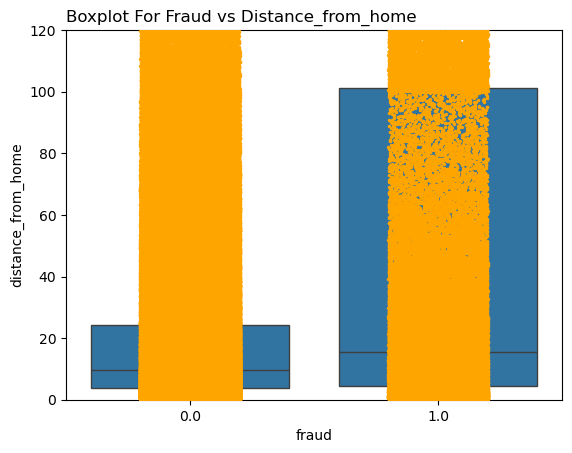

In [42]:
ax = sns.boxplot(x='fraud', y='distance_from_home', data=df2)
ax = sns.stripplot(x='fraud', y='distance_from_home', data=df2, color="orange", jitter=0.2, size=2.5)
plt.title("Boxplot For Fraud vs Distance_from_home", loc="left")
plt.ylim(0, 120)
plt.show()

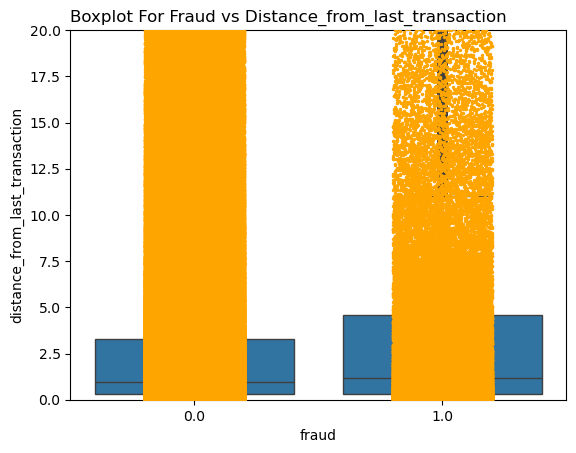

In [62]:
ax = sns.boxplot(x='fraud', y='distance_from_last_transaction', data=df2)
ax = sns.stripplot(x='fraud', y='distance_from_last_transaction', data=df2, color="orange", jitter=0.2, size=2.5)
plt.title("Boxplot For Fraud vs Distance_from_last_transaction", loc="left")
plt.ylim(0, 20)
plt.show()

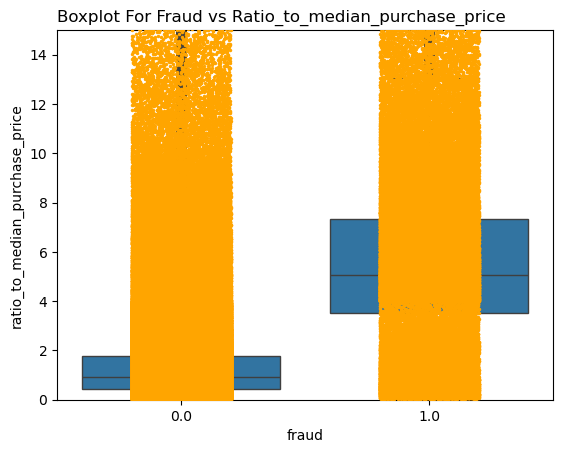

In [68]:
ax = sns.boxplot(x='fraud', y='ratio_to_median_purchase_price', data=df2)
ax = sns.stripplot(x='fraud', y='ratio_to_median_purchase_price', data=df2, color="orange", jitter=0.2, size=2.5)
plt.title("Boxplot For Fraud vs Ratio_to_median_purchase_price", loc="left")
plt.ylim(0, 15)
plt.show()

In [70]:
table_1 = pd.crosstab(df2['repeat_retailer'], df2['fraud'])
table_1_percent =table_1.div(table_1.sum(axis=0), axis=1) * 100
print(table_1_percent)

fraud                  0.0        1.0
repeat_retailer                      
0.0              11.832824  11.988147
1.0              88.167176  88.011853


In [72]:
table_2 = pd.crosstab(df2['used_chip'], df2['fraud'])
table_2_percent =table_2.div(table_2.sum(axis=0), axis=1) * 100
print(table_2_percent)

fraud           0.0        1.0
used_chip                     
0.0        64.05982  74.360148
1.0        35.94018  25.639852


In [74]:
table_3 = pd.crosstab(df2['used_pin_number'], df2['fraud'])
table_3_percent =table_3.div(table_3.sum(axis=0), axis=1) * 100
print(table_3_percent)

fraud                  0.0        1.0
used_pin_number                      
0.0              89.005552  99.687654
1.0              10.994448   0.312346


In [76]:
table_4 = pd.crosstab(df2['online_order'], df2['fraud'])
table_4_percent =table_4.div(table_4.sum(axis=0), axis=1) * 100
print(table_4_percent)

fraud               0.0        1.0
online_order                      
0.0           37.777464   5.368237
1.0           62.222536  94.631763


The exploratory analysis shows that the variables most correlated with fraud are online_order, used_pin_number, used_chip and ratio_to_median_purchase_price.

# Anomaly Detection Algorithm Implementation

## Isolation Forest

In [111]:
model = IsolationForest(contamination=0.1) 
model.fit(df.iloc[:,:7])

predictions = model.predict(df.iloc[:,:7])

anomalies = df.iloc[predictions == -1]
normal_data = df.iloc[predictions == 1]

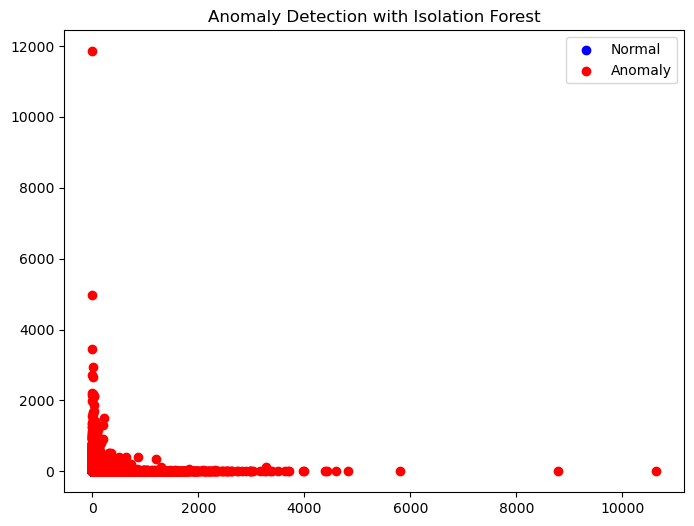

In [100]:
plt.figure(figsize=(8, 6))
plt.scatter(normal_data.iloc[:, 0], normal_data.iloc[:, 1], color='blue', label='Normal')
plt.scatter(anomalies.iloc[:, 0], anomalies.iloc[:, 1], color='red', label='Anomaly')
plt.title('Anomaly Detection with Isolation Forest')
plt.legend()
plt.show()

In [88]:
df2['Anomaly'] = predictions
df2['Anomaly'] = df2['Anomaly'].astype('object')

table_5 = pd.crosstab(df2['Anomaly'], df2['fraud'])
table_5_percent =table_5.div(table_5.sum(axis=0), axis=1) * 100
print(table_5_percent)

fraud          0.0        1.0
Anomaly                      
-1        2.501542  31.082457
 1       97.498458  68.917543


With anomaly prediction we see that there is a correlation between what is an anomaly and fraud, i.e., detecting these anomalies will help classify transactions as suspicious in order to detect a pattern of fraud and thus prevent it, capturing at most 31% of fraud.